# Aprendizaje inductivo - ID3 & J48

El dataset que usaremos para el notebook de ejemplo es el siguiente: [German Credit Card](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

Este dataset clasifica a las personas descritas según un conjunto de atributos como riesgos crediticios buenos o malos.

## Importación librerías

In [3]:
import pandas as pd
import numpy as np
import pydot

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from IPython.display import Image
from six import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,classification_report
from IPython.display import Image

## Carga de datos

In [4]:
df= pd.read_csv('Credit_g.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      1000 non-null   int64 
 1   checking_status         1000 non-null   object
 2   duration                1000 non-null   int64 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_status          1000 non-null   object
 7   employment              1000 non-null   object
 8   installment_commitment  1000 non-null   int64 
 9   personal_status         1000 non-null   object
 10  other_parties           1000 non-null   object
 11  residence_since         1000 non-null   int64 
 12  property_magnitude      1000 non-null   object
 13  age                     1000 non-null   int64 
 14  other_payment_plans     1000 non-null   object
 15  housi

In [6]:
df.set_index('id', inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  existing_

In [8]:
# Resumen de la variable objetivo "Class"
class_summary = df['class'].value_counts()
print(class_summary)

# 1. Missing values
missing_values = df.isnull().sum()
print(missing_values)

class
good    700
bad     300
Name: count, dtype: int64
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


## Transformación de datos categóricos a numéricos

In [9]:
# 2. Transformación de datos categóricos a numéricos
X = df.copy()
df_c = df

for column in X.columns:
    if X[column].dtype == 'object':
        df_c[column] = LabelEncoder().fit_transform(df_c[column])
df_c

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
id,,,,,,,,,,,,,,,,,,,,,
1,1,6,1,6,1169,4,3,4,3,2,...,3,67,1,1,2,1,1,1,1,1
2,0,48,3,6,5951,2,0,2,0,2,...,3,22,1,1,1,1,1,0,1,0
3,3,12,1,2,2096,2,1,2,3,2,...,3,49,1,1,1,3,2,0,1,1
4,1,42,3,3,7882,2,1,2,3,1,...,1,45,1,0,1,1,2,0,1,1
5,1,24,2,4,4870,2,0,3,3,2,...,2,53,1,0,2,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,3,12,3,3,1736,2,1,3,0,2,...,3,31,1,1,1,3,1,0,1,1
997,1,30,3,9,3857,2,0,4,1,2,...,1,40,1,1,1,0,1,1,1,1
998,3,12,3,6,804,2,3,4,3,2,...,0,38,1,1,1,1,1,0,1,1


In [10]:
df.describe()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.582000,20.903000,2.219000,4.484000,3271.258000,2.1450,1.525000,2.973000,1.878000,1.866000,...,1.386000,35.546000,0.908000,1.071000,1.407000,1.274000,1.155000,0.404000,0.963000,0.700000
std,1.253334,12.058814,1.064035,2.421075,2822.736876,1.1114,1.344315,1.118715,1.350904,0.445244,...,1.210979,11.375469,0.421561,0.531264,0.577654,0.946478,0.362086,0.490943,0.188856,0.458487
min,0.000000,4.000000,0.000000,0.000000,250.000000,0.0000,0.000000,1.000000,0.000000,0.000000,...,0.000000,19.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,12.000000,1.000000,3.000000,1365.500000,2.0000,0.000000,2.000000,0.000000,2.000000,...,0.000000,27.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,18.000000,3.000000,4.000000,2319.500000,2.0000,1.000000,3.000000,3.000000,2.000000,...,1.000000,33.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,3.000000,24.000000,3.000000,6.000000,3972.250000,2.0000,3.000000,4.000000,3.000000,2.000000,...,3.000000,42.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,3.000000,72.000000,4.000000,9.000000,18424.000000,4.0000,4.000000,4.000000,3.000000,2.000000,...,3.000000,75.000000,2.000000,2.000000,4.000000,3.000000,2.000000,1.000000,1.000000,1.000000


In [11]:
# Separar en atributos (X) y etiquetas (y)
X = df_c.iloc[:, :-1].values
y = df_c.iloc[:, -1].values

In [12]:
# 3. Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model_params={
    'max_leaf_nodes':[50,100,500,5000],
    'min_samples_split':[2,4,6]
}

In [14]:
# 4. Predecir con árboles
model = DecisionTreeClassifier(random_state=42)
gscv = GridSearchCV(model, model_params, cv=5, verbose=1, n_jobs=-1)
model_gs = gscv.fit(X_train, y_train)
print("Best: %f using %s" % (model_gs.best_score_, model_gs.best_params_))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best: 0.701250 using {'max_leaf_nodes': 50, 'min_samples_split': 2}


In [15]:
# Optimum decision tree
model = DecisionTreeClassifier(max_leaf_nodes=model_gs.best_params_['max_leaf_nodes'], min_samples_split=model_gs.best_params_['min_samples_split'], random_state=42)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

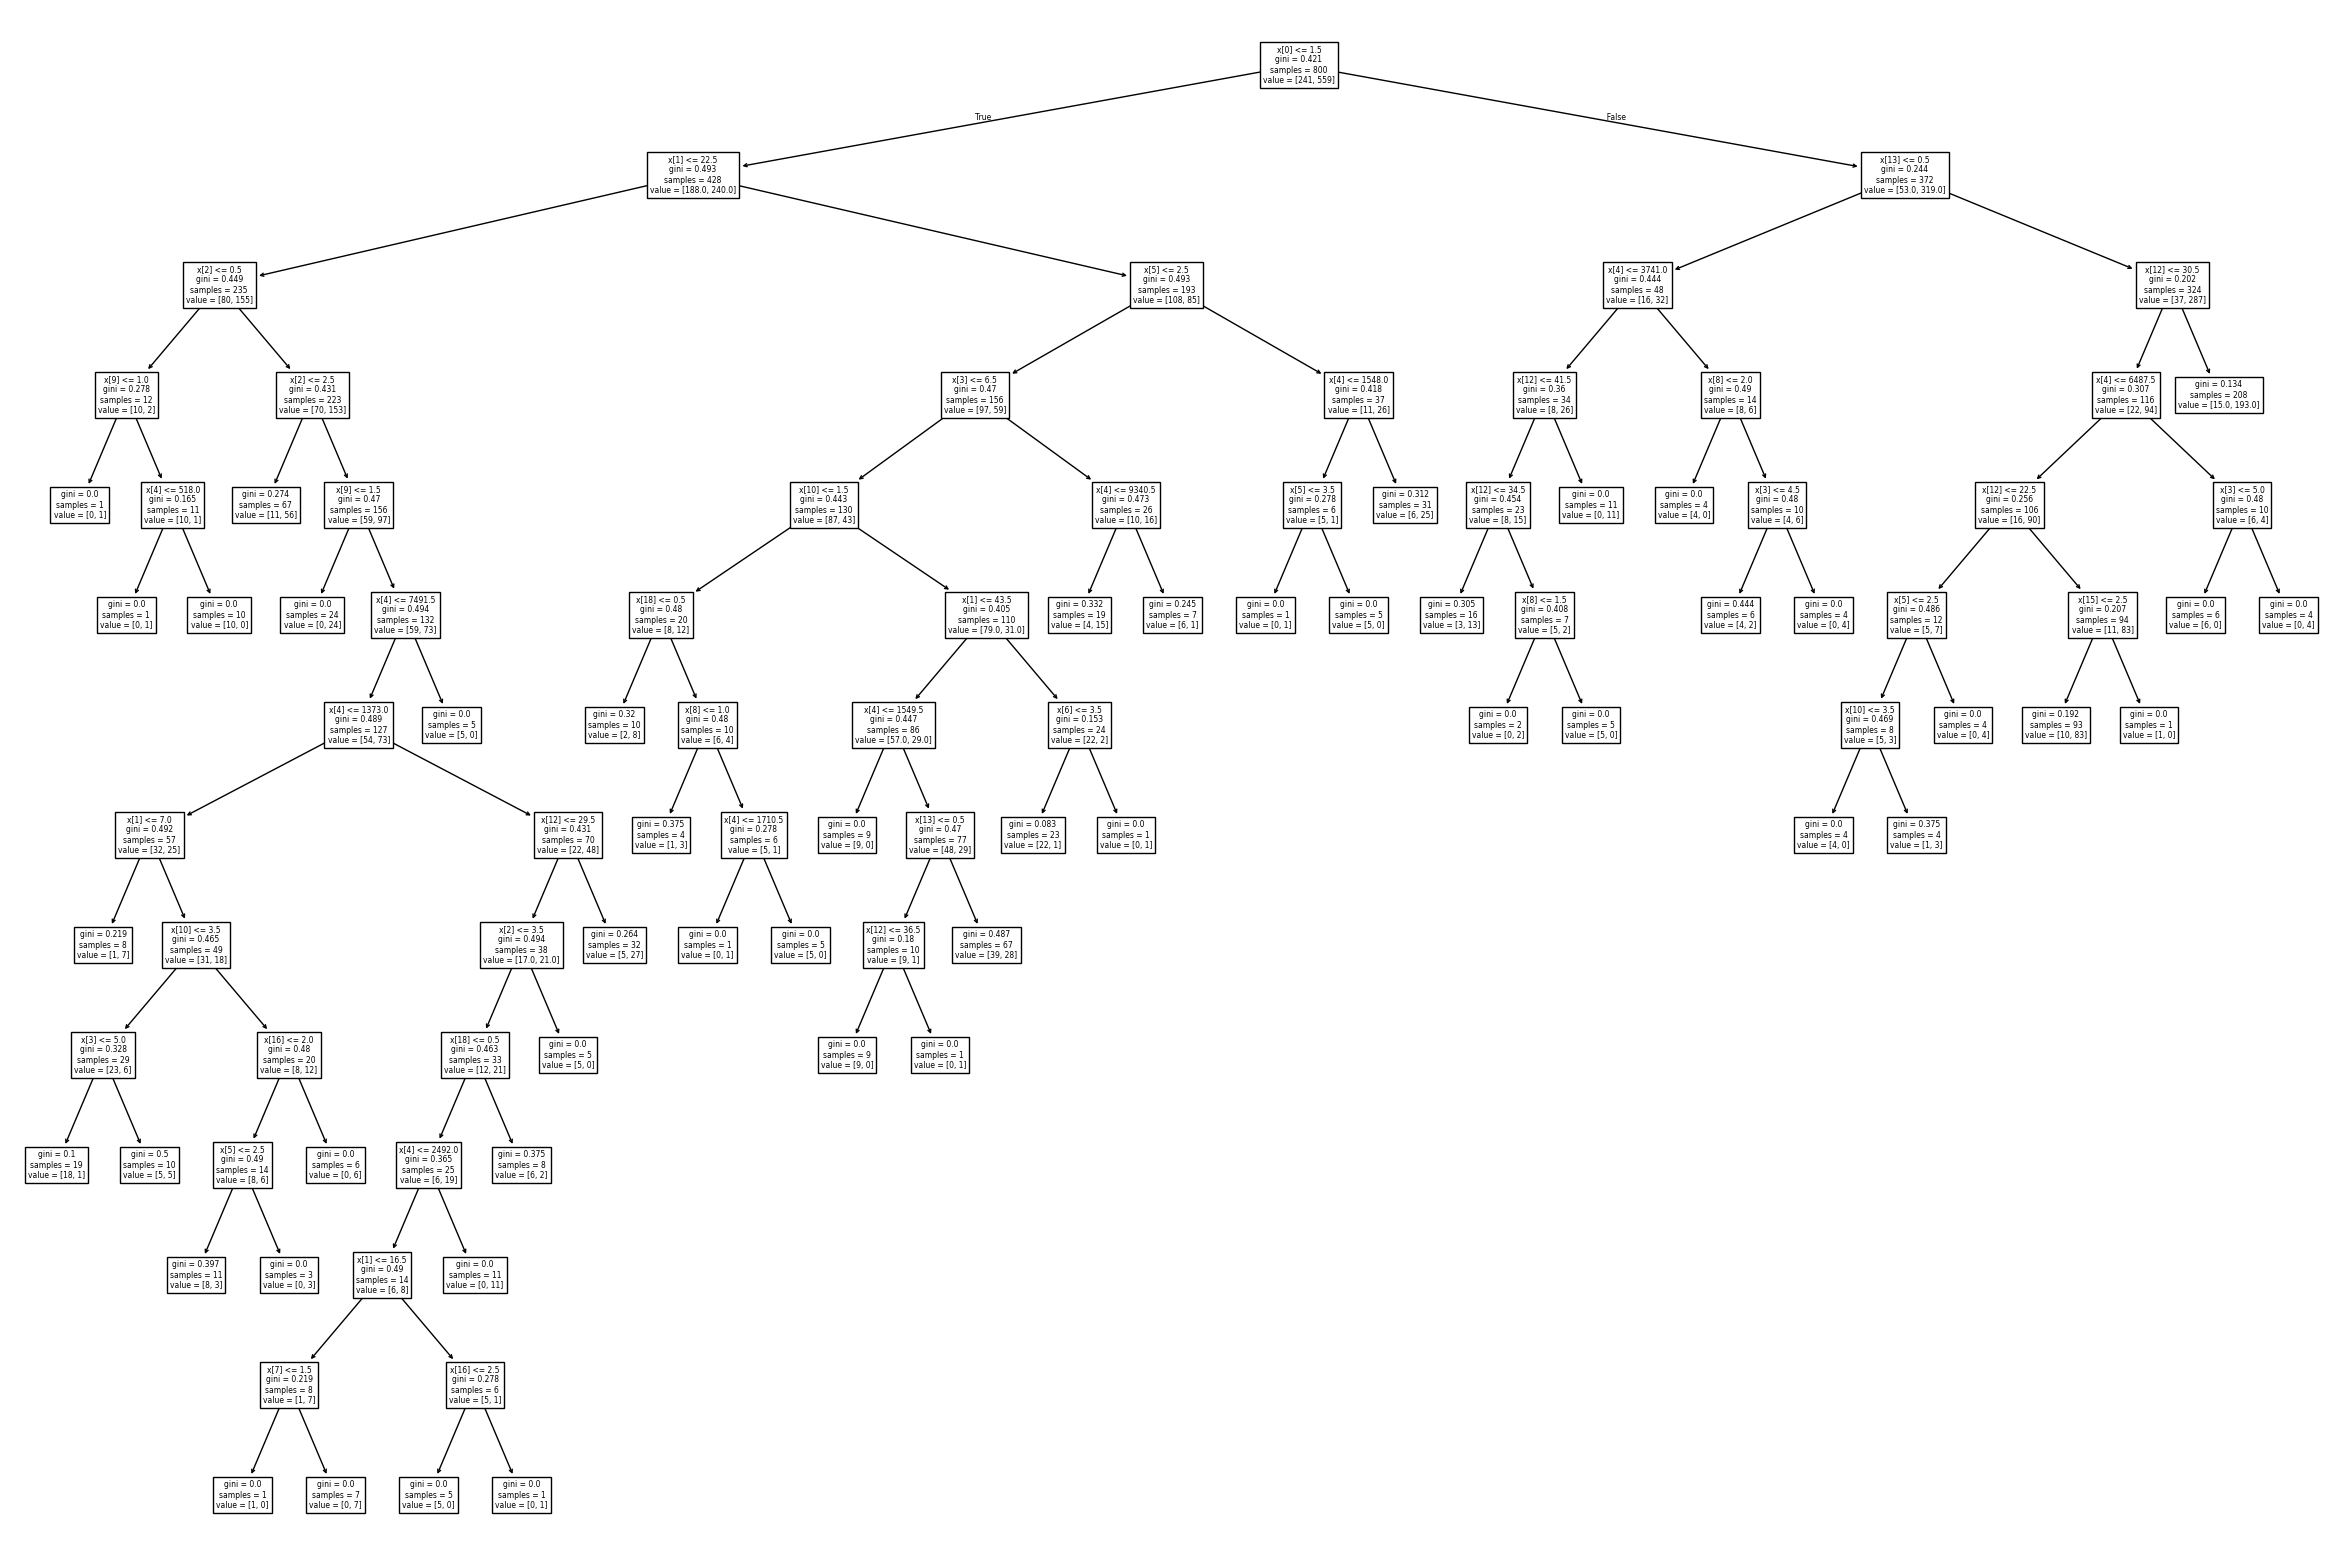

In [16]:
from sklearn import tree
plt.figure(figsize=(30, 20))
tree.plot_tree(model)
plt.savefig("breast_cancer_tree.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
plt.savefig("breast_cancer_tree.png", dpi=300, bbox_inches='tight')
plt.show()

print("File saved as breast_cancer_tree.png")

<Figure size 640x480 with 0 Axes>

File saved as breast_cancer_tree.png
